# Network and graph visualizations

Turn an explicit edge table into adjacency matrices, directed graphs, coordinate views, response matrices, and dynamic metric panels.

All signals, labels, and coordinates in this notebook are deterministic and
synthetic. They do not represent a participant. Run cells from top to bottom.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow this notebook to run from JupyterLab or from the repository root.
HERE = Path.cwd()
EXAMPLES = HERE if (HERE / "_synthetic.py").exists() else HERE / "notebooks" / "examples"
sys.path.insert(0, str(EXAMPLES.resolve()))
REPOSITORY = EXAMPLES.parents[1]
if (REPOSITORY / "ERPy").exists():
    sys.path.insert(0, str(REPOSITORY.resolve()))

import ERPy as ep
import ERPy.viz as viz
from IPython.display import Image, display as show_output
from _synthetic import (
    make_detection_table,
    make_edges,
    make_electrode_metadata,
    make_epochs,
    make_metric_table,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

# The publication workflow stores PNGs so the figures render directly on GitHub.
get_ipython().run_line_magic("matplotlib", "inline")

def show_plotly_snapshot(figure):
    # Use figure.show() to interact locally; these PNGs also render on GitHub.
    import plotly.graph_objects as go
    preview = go.Figure(figure)
    preview.layout.sliders = ()
    preview.layout.updatemenus = ()
    preview.update_layout(
        legend={"orientation": "h", "y": -0.08, "x": 0.05},
        margin={"l": 30, "r": 100, "t": 65, "b": 70},
    )
    show_output(Image(preview.to_image(format="png", width=1000, height=650, scale=1)))

In [2]:
edges = make_edges()
metadata = make_electrode_metadata()
metrics = make_metric_table()
epochs = make_epochs()
detections = make_detection_table(epochs)
derived_edges = viz.edges_from_detections(
    detections, stim_pair="STIM_A_1_2", elec_meta=metadata,
    significance_column="primary_significant", qc_only=False,
)
print("Canonical identity:", viz.electrode_label_identity("STIM_A_1"))
derived_edges.head()

Canonical identity: STIMA1


,stim_pair,stim_elec,record_elec,source,target,weight,peak_amplitude_uv,stim_region,record_region,stim_mni_x,stim_mni_y,stim_mni_z,record_mni_x,record_mni_y,record_mni_z
0,STIM_A_1_2,STIM_A1,CONTACT_B1,STIM_A1,CONTACT_B1,27.0,27.0,left frontal,left temporal,-31.0,20.0,31.0,-48.0,-12.0,5.0


In [3]:
adjacency = viz.adjacency_from_edges(edges)
ordered = viz.ordered_adjacency_from_edges(edges, metadata)
response_matrix = viz.response_matrix_from_edges(edges, metadata)
graph = viz.graph_from_edges(edges)
graph_from_matrix = viz.graph_from_matrix(adjacency)
print("Resolved label:", viz.resolve_electrode_label("STIM_A_1", metadata.elec_label.tolist()))
print("Stim contacts:", viz.stim_pair_to_contact_electrodes("STIM_A_1_2"))
print("Node order:", viz.order_nodes_by_metadata(list(graph.nodes), metadata))

Resolved label: STIM_A1
Stim contacts: ('STIM_A1', 'STIM_A2')
Node order: ['CONTACT_B1', 'CONTACT_B2', 'STIM_A1', 'STIM_A2', 'CONTACT_C1', 'CONTACT_C2']


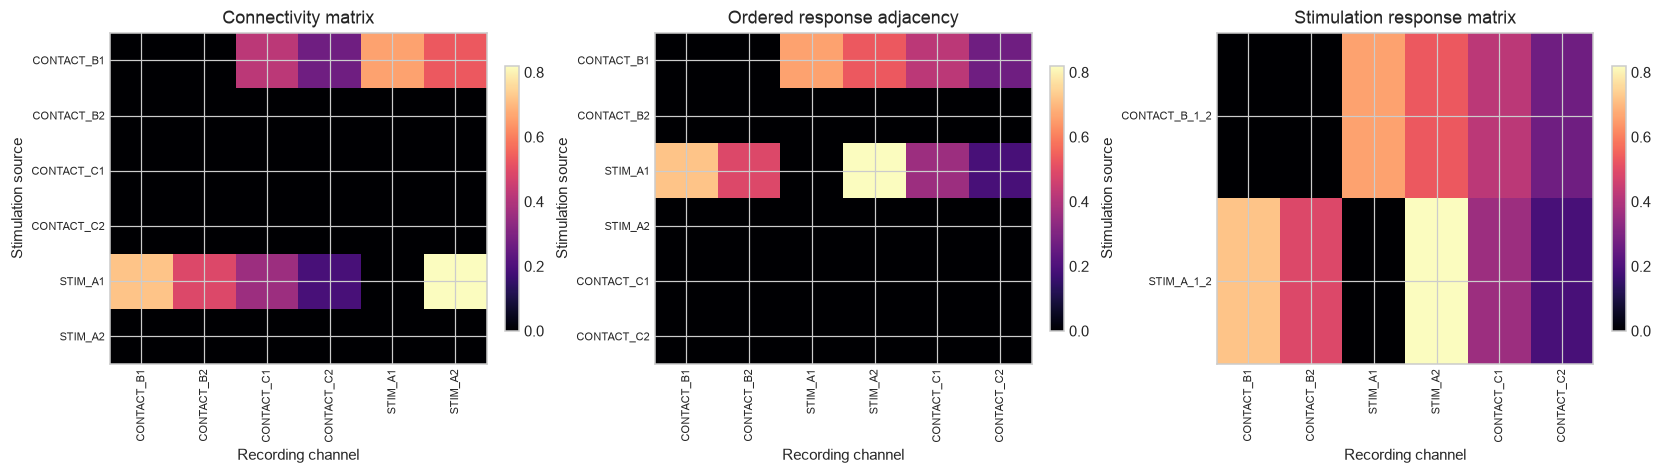

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), layout="constrained")
viz.plot_adjacency_heatmap(adjacency, ax=axes[0])
viz.plot_ordered_adjacency_heatmap(edges, metadata, ax=axes[1])
viz.plot_response_matrix_heatmap(edges, metadata, ax=axes[2])
plt.show()

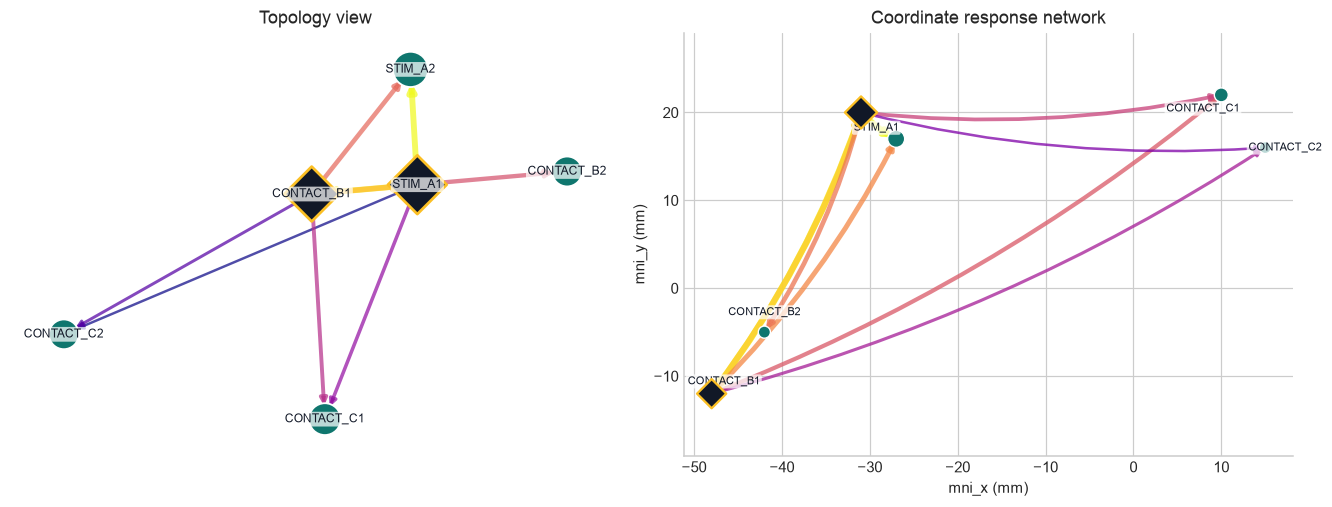

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
viz.plot_network(graph, ax=axes[0], title="Topology view")
viz.plot_coordinate_network(edges, metadata, ax=axes[1], top_n=None)
plt.show()

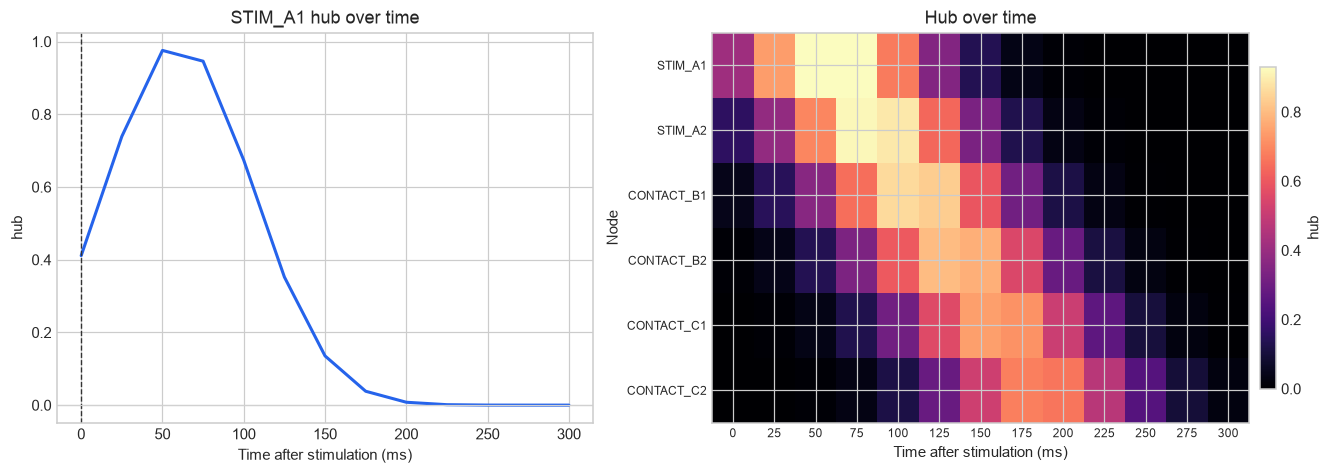

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")
viz.plot_graph_metric_timecourse(metrics, node="STIM_A1", metric="hub", ax=axes[0])
viz.plot_graph_metric_heatmap(metrics, metric="hub", top_n_nodes=6, ax=axes[1])
plt.show()

In [7]:
coords = viz.node_coordinates_from_metadata(metadata, list(graph.nodes))
sources = viz.order_sources_by_metadata(edges.stim_elec.unique().tolist(), metadata)
qc = viz.validate_mni_coordinates(metadata)
print("Sources:", sources)
coords

Sources: ['CONTACT_B1', 'STIM_A1']


,node,x,y,z,region
0,STIM_A1,-31.0,20.0,31.0,left frontal
1,STIM_A2,-27.0,17.0,28.0,left frontal
2,CONTACT_B1,-48.0,-12.0,5.0,left temporal
3,CONTACT_B2,-42.0,-5.0,9.0,left temporal
4,CONTACT_C1,10.0,22.0,24.0,right cingulate
5,CONTACT_C2,15.0,16.0,20.0,right cingulate
